# Chapter 1: Neural Networks

- What can neural networks do? 
### Play some game! 
The goal is to create a simple game that can be played by learning a function. Which games can be played when the underlying function is very simple - ideally one which requires 1 or 2 inputs only. This is important because we can visualise the function learned by the neural network.
### Examples of simple games:
- Tic Tac Toe


- What are neurons? 
- Activation Functions
- Forward Pass
- Backpropagation
- Stochastic Gradient Descent and how it helps 

-> Some theory time
- Universal Function Approximation Theorem
- Wide and Deep Networks


In [5]:
input_clear_game_history = input("Clear game history? True/False or 1/0 or yes/no or y/n")
if input_clear_game_history in ["True", "true", "1", "yes", "y"]:
    clear_game_history = True
elif input_clear_game_history in ["False", "false", "0", "no", "n"]:
    clear_game_history = False
else:
    print("Invalid input!")
    clear_game_history = None

if clear_game_history:
    if 'all_user_inputs' in locals():
        print("Current game history is")
        print(all_user_inputs) 
        all_user_inputs = []
        print("Cleared!")
    else:
        print("Nothing to clear!")
        all_user_inputs = []

Nothing to clear!


In [16]:
mapping = { \
    "A1" : 0,
    "A2" : 1,
    "A3" : 2,
    "B1" : 3,
    "B2" : 4,
    "B3" : 5,
    "C1" : 6,
    "C2" : 7,
    "C3" : 8
}

def show_game_state(game_state):
    assert len(game_state) == 9, "Game state must have exactly 9 elements."
    print(f"\t | 1 \t| 2 \t| 3")
    print(f"---------------------------------")
    print(f"A \t| {game_state[0]} \t| {game_state[1]} \t| {game_state[2]}")
    print(f"---------------------------------")
    print(f"B \t| {game_state[3]} \t| {game_state[4]} \t| {game_state[5]}")
    print(f"---------------------------------")
    print(f"C \t| {game_state[6]} \t| {game_state[7]} \t| {game_state[8]}")
    print(f"---------------------------------")

def is_game_over(game_state):
    assert len(game_state) == 9, "Game state must have exactly 9 elements."
    game_state_2d = game_state.reshape(3, 3)
    # numbers = +1 or -1 for players, 0 for empty

    row_sums = game_state_2d.sum(axis=1)
    col_sums = game_state_2d.sum(axis=0)
    diag1_sum = game_state_2d.trace()
    game_state_flipped = np.fliplr(game_state_2d)
    diag2_sum = game_state_flipped.trace()
    winning_sums = [3, -3]
    all_sums = list(row_sums) + list(col_sums) + [diag1_sum, diag2_sum]
    for s in all_sums:
        if s in winning_sums:
            return True, s
    
    unique, counts = np.unique(game_state, return_counts=True)
    if 0 not in unique:
        return True, 0

    return False, 0



In [85]:
def run_random_game(verbose=False):
    game_state = np.zeros(9, dtype=int)
    current_player = np.random.choice([-1, 1])
    first_player = current_player.copy()
    opponent = -current_player
    game_over = False
    all_user_inputs = [(game_state.copy(), 0, -1)]  # Initial state with no move
    while not game_over:
        available_moves = np.where(game_state == 0)[0]
        chosen_move = np.random.choice(available_moves)
        all_user_inputs.append((game_state.copy(), current_player, chosen_move))
        game_state[chosen_move] = current_player
        game_over, result = is_game_over(game_state)
        if game_over:
            if verbose:
                show_game_state(game_state)
            if result == 3:
                if verbose:
                    print("Player 1 wins!")
            elif result == -3:
                if verbose:
                    print("Player 2 wins!")
            else:
                if verbose:
                    print("It's a draw!")
            who_won = 1 if result == 3 else (-1 if result == -3 else 0)
            first_player_won = True if who_won == first_player else False
            return who_won, all_user_inputs, first_player_won
        
        current_player, opponent = opponent, current_player



In [90]:
from tqdm import tqdm

list_of_who_won = []
list_of_first_player_won = []
list_of_next_moves = []
for i in tqdm(range(10000)):
    who_won, all_user_inputs, first_player_won = run_random_game(verbose=False)
    list_of_who_won.append(who_won)
    list_of_first_player_won.append(first_player_won)
    list_of_next_moves.append([(x[0], x[2]) for x in all_user_inputs])  # Store only game states



100%|██████████| 10000/10000 [00:07<00:00, 1393.72it/s]


[[(array([0, 0, 0, 0, 0, 0, 0, 0, 0]), -1),
  (array([0, 0, 0, 0, 0, 0, 0, 0, 0]), 1),
  (array([0, 1, 0, 0, 0, 0, 0, 0, 0]), 4),
  (array([ 0,  1,  0,  0, -1,  0,  0,  0,  0]), 5),
  (array([ 0,  1,  0,  0, -1,  1,  0,  0,  0]), 8),
  (array([ 0,  1,  0,  0, -1,  1,  0,  0, -1]), 2),
  (array([ 0,  1,  1,  0, -1,  1,  0,  0, -1]), 6),
  (array([ 0,  1,  1,  0, -1,  1, -1,  0, -1]), 3),
  (array([ 0,  1,  1,  1, -1,  1, -1,  0, -1]), 7)],
 [(array([0, 0, 0, 0, 0, 0, 0, 0, 0]), -1),
  (array([0, 0, 0, 0, 0, 0, 0, 0, 0]), 2),
  (array([0, 0, 1, 0, 0, 0, 0, 0, 0]), 8),
  (array([ 0,  0,  1,  0,  0,  0,  0,  0, -1]), 6),
  (array([ 0,  0,  1,  0,  0,  0,  1,  0, -1]), 4),
  (array([ 0,  0,  1,  0, -1,  0,  1,  0, -1]), 0),
  (array([ 1,  0,  1,  0, -1,  0,  1,  0, -1]), 5),
  (array([ 1,  0,  1,  0, -1, -1,  1,  0, -1]), 7),
  (array([ 1,  0,  1,  0, -1, -1,  1,  1, -1]), 3)],
 [(array([0, 0, 0, 0, 0, 0, 0, 0, 0]), -1),
  (array([0, 0, 0, 0, 0, 0, 0, 0, 0]), 6),
  (array([ 0,  0,  0,  0,  

<Axes: ylabel='Probability'>

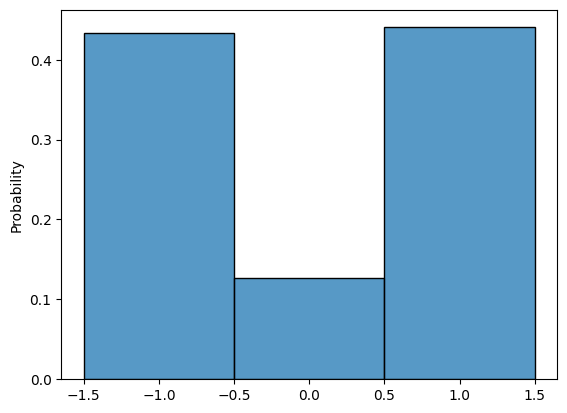

In [77]:
import seaborn as sns

sns.histplot(list_of_who_won, discrete=True, stat="probability")

In [23]:
import numpy as np 
from IPython.display import clear_output

game_is_running = True
user_inputs_for_this_game = []
evolution_of_game_states = []
game_state = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0])
who_plays_first = np.random.choice(["user", "computer"])
while game_is_running:
    clear_output()
    print(f"{who_plays_first} plays first!")
    
    print("Current game state:")
    if who_plays_first == "computer" and len(user_inputs_for_this_game) == 0:
        computer_move = np.random.choice(np.where(game_state == 0)[0])
        game_state[computer_move] = -1
        evolution_of_game_states.append((game_state.copy(), computer_move))
        who_plays_first = "user"
        show_game_state(game_state)
    else:
        show_game_state(game_state)
    user_input = input("Enter user input: ")
    user_inputs_for_this_game.append(user_input)
    evolution_of_game_states.append((game_state.copy(), user_input))
    if user_input in ["A1", "A2", "A3", "B1", "B2", "B3", "C1", "C2", "C3"]:
        number = mapping[user_input]
        game_state[number] = 1
        check_if_game_over, who_won = is_game_over(game_state)
        if check_if_game_over:
            game_is_running = False
            show_game_state(game_state)
            print("Game Over!")
            if who_won == 3:
                print("User wins!")
            elif who_won == -3:
                print("Computer wins!")
            else:
                print("It's a draw!")
            all_user_inputs.append(user_inputs_for_this_game)
            print("All inputs from this game session:", user_inputs_for_this_game)
        
        else:
            computer_move = np.random.choice(np.where(game_state == 0)[0])
            game_state[computer_move] = -1
            evolution_of_game_states.append((game_state.copy(), computer_move))
        
        check_if_game_over, who_won = is_game_over(game_state)
        if check_if_game_over:
            game_is_running = False
            show_game_state(game_state)
            print("Game Over!")
            if who_won == 3:
                print("User wins!")
            elif who_won == -3:
                print("Computer wins!")
            else:
                print("It's a draw!")
            all_user_inputs.append(user_inputs_for_this_game)
            print("All inputs from this game session:", user_inputs_for_this_game)
    elif user_input in ["exit", "quit"]:
        print("Exiting game...")
        game_is_running = False
        all_user_inputs.append(user_inputs_for_this_game)
            

        

user plays first!
Current game state:
	 | 1 	| 2 	| 3
---------------------------------
A 	| 1 	| 1 	| 0
---------------------------------
B 	| 0 	| 1 	| -1
---------------------------------
C 	| -1 	| 0 	| -1
---------------------------------
	 | 1 	| 2 	| 3
---------------------------------
A 	| 1 	| 1 	| 1
---------------------------------
B 	| 0 	| 1 	| -1
---------------------------------
C 	| -1 	| 0 	| -1
---------------------------------
Game Over!
User wins!
All inputs from this game session: ['A1', 'B2', 'A2', 'A3']
	 | 1 	| 2 	| 3
---------------------------------
A 	| 1 	| 1 	| 1
---------------------------------
B 	| 0 	| 1 	| -1
---------------------------------
C 	| -1 	| 0 	| -1
---------------------------------
Game Over!
User wins!
All inputs from this game session: ['A1', 'B2', 'A2', 'A3']


In [24]:
evolution_of_game_states

[(array([0, 0, 0, 0, 0, 0, 0, 0, 0]), 'A1'),
 (array([ 1,  0,  0,  0,  0,  0,  0,  0, -1]), 8),
 (array([ 1,  0,  0,  0,  0,  0,  0,  0, -1]), 'B2'),
 (array([ 1,  0,  0,  0,  1, -1,  0,  0, -1]), 5),
 (array([ 1,  0,  0,  0,  1, -1,  0,  0, -1]), 'A2'),
 (array([ 1,  1,  0,  0,  1, -1, -1,  0, -1]), 6),
 (array([ 1,  1,  0,  0,  1, -1, -1,  0, -1]), 'A3')]

# Structure 

-> Play the game! 

-> Main content: 
- What is a Neuron? Show the comparison between biological and artificial neuron. 
- Explain Activation functions: Sigmoid, ReLU, Tanh. Define them using numpy 
- Explain Forward Pass with a simple example. Define using numpy
- Explain Backpropagation with a simple example. Define using numpy
- Explain Stochastic Gradient Descent and how it helps. Define using numpy

-> Why does Neural Networks work?
- Compare polynomial regression with neural networks. Show benign overfitting. How does this work? Discuss. 
- Universal Function Approximation Theorem
- Wide and Deep Networks

-> How to build a Neural Network using PyTorch? 
- Define a simple feedforward neural network using PyTorch
- Visualise the learned function using matplotlib
- Visualise the loss landscape. What factors affect the loss landscape? What factors affect convergence?

-> Assignments:
- Implement a simple neural network from scratch using numpy to play Tic Tac Toe.

# What is a neuron? 


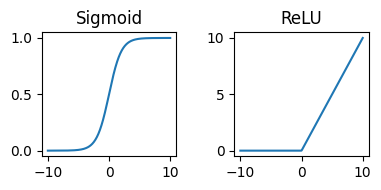

In [8]:
import matplotlib.pyplot as plt

def activation_function(z, function_type="sigmoid"):
    if function_type == "sigmoid":
        return 1 / (1 + np.exp(-z))
    elif function_type == "relu":
        return np.maximum(0, z)
    else:
        raise ValueError("Unsupported activation function.")
    
def neuron(input, weight, bias, activation_function_type="sigmoid"):
    z = np.dot(input, weight) + bias
    output = activation_function(z, function_type=activation_function_type)
    return output

# plot sigmoid and relu

z = np.linspace(-10, 10, 400)
sigmoid_values = activation_function(z, function_type="sigmoid")
relu_values = activation_function(z, function_type="relu")
fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].plot(z, sigmoid_values)
ax[0].set_title("Sigmoid")
ax[1].plot(z, relu_values)
ax[1].set_title("ReLU")
plt.tight_layout()



# Create a layer 


In [16]:
def layer(**neurons):
    layer_output = {}
    for neuron_name, neuron_params in neurons.items():
        input = neuron_params['input']
        weight = neuron_params['weight']
        bias = neuron_params['bias']
        activation_function_type = neuron_params['activation_function_type']
        output = neuron(input, weight, bias, activation_function_type=activation_function_type)
        layer_output[neuron_name] = output
    return layer_output

In [22]:
# Create a layer with 3 neurons
input_vector = np.array([2])
output_vector = np.array([4])
weight_vector = np.array([0.5, -1.5, 1.0])
bias_vector = np.array([0.0, 1.0, -1.0])
activation_function_string = "sigmoid"

layer_output = layer(
    neuron1={
        'input': input_vector,
        'weight': weight_vector[0],
        'bias': bias_vector[0],
        'activation_function_type': activation_function_string
    },
    neuron2={
        'input': input_vector,
        'weight': weight_vector[1],
        'bias': bias_vector[1],
        'activation_function_type': activation_function_string
    },
    neuron3={
        'input': input_vector,
        'weight': weight_vector[2],
        'bias': bias_vector[2],
        'activation_function_type': activation_function_string
    }
)
layer_output

{'neuron1': array([0.73105858]),
 'neuron2': array([0.11920292]),
 'neuron3': array([0.73105858])}

In [23]:
np.asarray(list(layer_output.values()))

array([[0.73105858],
       [0.11920292],
       [0.73105858]])

In [24]:
last_layer_weights = np.array([0.2, -0.4, 0.6])
last_layer_bias = 0.1
final_output = neuron(
    input=np.array(list(layer_output.values())).reshape(-1),
    weight=last_layer_weights,
    bias=last_layer_bias,
    activation_function_type="sigmoid"
)
final_output

0.6541124811672111

In [25]:
# Compute the loss 
def loss_function(predicted, actual, function_type="mse"):
    if function_type == "mse":
        return np.mean((predicted - actual) ** 2)
    elif function_type == "cross_entropy":
        return -np.mean(actual * np.log(predicted) + (1 - actual) * np.log(1 - predicted))
    else:
        raise ValueError("Unsupported loss function.")

In [27]:
loss_value = loss_function(predicted=final_output, actual=output_vector, function_type="mse")
print("Loss value:", loss_value)

Loss value: 11.194963288681038


## Backpropagation (Gradient Descent)

In [29]:
# Calculate the gradient of the loss with respect to the final output
def loss_gradient(predicted, actual, function_type="mse"):
    if function_type == "mse":
        return 2 * (predicted - actual) / actual.size
    elif function_type == "cross_entropy":
        return -(actual / predicted) + ((1 - actual) / (1 - predicted))
    else:
        raise ValueError("Unsupported loss function.")
gradient_value = loss_gradient(predicted=final_output, actual=output_vector, function_type="mse")
print("Gradient value:", gradient_value)

Gradient value: [-6.69177504]
